# Análisis del Impacto de la Inteligencia Artificial en el Sector Laboral



**Taller 1**

**Autor:** Daniel Alejandro Cuaspa Arellano

**Fecha:** Abril de 2026

**Dataset:** [AI Impact on Job Sector – Kaggle](https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector)



## Descripción

Este trabajo analiza cómo la adopción de la Inteligencia Artificial (IA) ha transformado distintos aspectos del entorno laboral, evaluando su impacto sobre los **salarios**, las **horas de trabajo** y la **productividad** de los empleados, según la industria, el rol y el nivel de adopción de IA.

A lo largo del documento se realiza la **carga**, **limpieza** y **exploración** del dataset, se construyen nuevas variables relevantes y se responden tres preguntas analíticas mediante agrupaciones, detección de valores atípicos y visualizaciones.



https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector

In [24]:
import pandas as pd
import numpy as np

In [25]:
import kagglehub as kagglehub

# Download latest version
path = kagglehub.dataset_download("sumeakash/ai-impact-on-job-sector")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\sumeakash\ai-impact-on-job-sector\versions\1


Crear el dataframe

In [26]:
data = pd.read_csv('ai_job_impact.csv')
data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ai_job_impact.csv'

## Exploración y Limpieza de Datos

In [ ]:
# Información general del dataset
data.describe()


,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,40.558000,16.663500,73942.072500,78428.642500,44.85100,6.020500,9.785820
std,10.786418,10.746675,26055.823793,29351.599013,5.71254,2.006263,17.187882
min,22.000000,0.000000,30036.000000,24447.000000,35.00000,3.000000,-19.990000
25%,32.000000,8.000000,51665.500000,54086.750000,40.00000,4.000000,-5.355000
50%,40.000000,16.000000,74620.000000,76820.500000,45.00000,6.000000,9.850000
75%,50.000000,26.000000,95418.250000,100730.250000,50.00000,8.000000,24.582500
max,59.000000,37.000000,119976.000000,161745.000000,54.00000,9.000000,39.990000


In [ ]:
# Limpieza de datos: eliminar duplicados por Employee_ID
duplicados = data['Employee_ID'].duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
data = data.drop_duplicates(subset='Employee_ID')

# Verificar y tratar valores nulos (rellenar numéricos con la mediana, categóricos con la moda)
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    data[col] = data[col].fillna(data[col].median())

for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# Estandarizar texto en columnas categóricas (quitar espacios extra, capitalizar)
for col in ['Gender', 'Education_Level', 'Industry', 'Job_Role', 'AI_Adoption_Level', 'Automation_Risk', 'Job_Status', 'Remote_Work']:
    data[col] = data[col].str.strip().str.title()

print("Limpieza completada.")
print(f"Dimensiones finales: {data.shape}")
data.head()

Duplicados encontrados: 0
Limpieza completada.
Dimensiones finales: (2000, 17)


C:\Users\User\AppData\Local\Temp\ipykernel_54064\2259859252.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include=['object']).columns:


,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,It,Devops Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,Phd,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


Creación de variables-Cambio Salarial

In [ ]:
data['Salary_Change'] = data['Salary_After_AI'] - data['Salary_Before_AI']
data['Salary_Change_%'] = ((data['Salary_After_AI'] - data['Salary_Before_AI']) / data['Salary_Before_AI']) * 100

print("Nuevas columnas creadas: Salary_Change, Salary_Change_%")
data[['Employee_ID', 'Salary_Before_AI', 'Salary_After_AI', 'Salary_Change', 'Salary_Change_%']].head(10)

Nuevas columnas creadas: Salary_Change, Salary_Change_%


,Employee_ID,Salary_Before_AI,Salary_After_AI,Salary_Change,Salary_Change_%
0,E0001,106820,95455,-11365,-10.639393
1,E0002,74131,72013,-2118,-2.857104
2,E0003,35311,42290,6979,19.764379
3,E0004,114478,107820,-6658,-5.815965
4,E0005,33890,40945,7055,20.817350
5,E0006,103969,104781,812,0.781002
6,E0007,78555,86183,7628,9.710394
7,E0008,99479,105776,6297,6.329979
8,E0009,102409,104197,1788,1.745940
9,E0010,31016,42699,11683,37.667655


## Preguntas de Análisis

### 1. ¿Cuál es el cambio salarial promedio por industria después de la adopción de IA, y qué industrias se beneficiaron más o se vieron más afectadas?

Agrupación por industria: cambio salarial promedio

In [ ]:
salary_by_industry = data.groupby('Industry').agg(
    Salario_Antes_Promedio=('Salary_Before_AI', 'mean'),
    Salario_Despues_Promedio=('Salary_After_AI', 'mean'),
    Cambio_Salarial_Promedio=('Salary_Change', 'mean'),
    Cambio_Salarial_Pct_Promedio=('Salary_Change_%', 'mean'),
    Empleados=('Employee_ID', 'count')
).sort_values('Cambio_Salarial_Promedio', ascending=False)

salary_by_industry.round(2)

,Salario_Antes_Promedio,Salario_Despues_Promedio,Cambio_Salarial_Promedio,Cambio_Salarial_Pct_Promedio,Empleados
Industry,,,,,
Healthcare,73128.74,78702.03,5573.29,7.59,270
Retail,75254.97,80376.96,5121.99,6.63,271
It,74847.38,79551.60,4704.22,6.23,298
Education,73839.21,78322.74,4483.53,6.06,293
Marketing,73196.50,77597.73,4401.23,6.08,273
Manufacturing,74792.29,78489.94,3697.64,4.70,295
Finance,72531.70,76106.43,3574.73,5.23,300


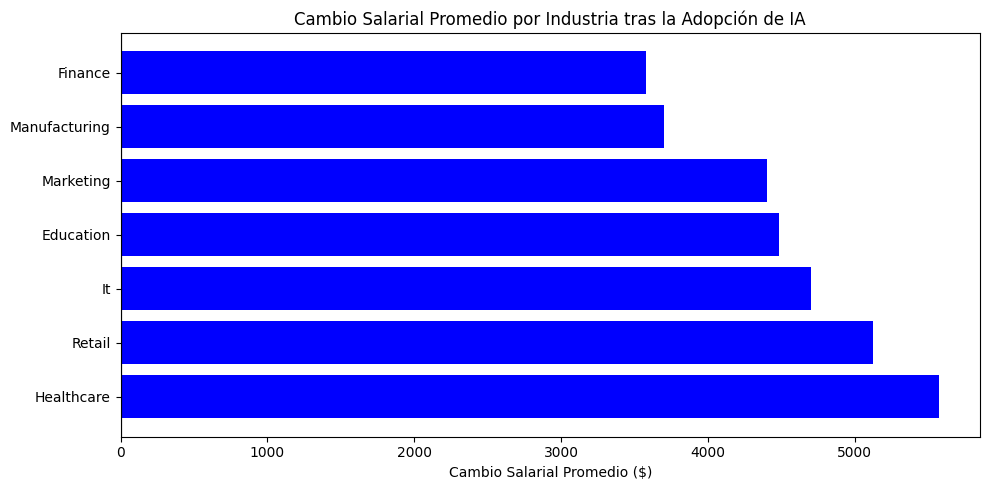

In [ ]:
# Visualización del cambio salarial por industria
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['blue' if x >= 0 else 'red' for x in salary_by_industry['Cambio_Salarial_Promedio']]
ax.barh(salary_by_industry.index, salary_by_industry['Cambio_Salarial_Promedio'], color=colors)
ax.set_xlabel('Cambio Salarial Promedio ($)')
ax.set_title('Cambio Salarial Promedio por Industria tras la Adopción de IA')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Respuesta 1:** Se calcularon `Salary_Change` y `Salary_Change_%` y se promediaron por industria. **Todas las industrias mostraron un cambio salarial promedio positivo**, pero con magnitudes distintas: **Healthcare** lidera con +$5,573 (7.59 %), seguida por **Retail** (+$5,122 / 6.63 %), **IT** (+$4,704 / 6.23 %), **Education** (+$4,484 / 6.06 %) y **Marketing** (+$4,401 / 6.08 %); las menos beneficiadas son **Manufacturing** (+$3,698 / 4.70 %) y **Finance** (+$3,575 / 5.23 %).

La diferencia se explica por el grado de automatización de cada sector: en Healthcare, IT, Education y Marketing la IA complementa tareas humanas y especializadas, lo que impulsa más los salarios; en Finance y Manufacturing, en cambio, la IA reemplaza procesos repetitivos y estructurados, reduciendo la presión al alza.

**Conclusión:** la IA no redujo salarios promedio en ningún sector, pero benefició más a las industrias con tareas difíciles de automatizar y menos a las que concentran procesos automatizables.



### 2. ¿Existen valores atípicos en las horas de trabajo semanales y cómo se distribuyen según el estado laboral (Replaced, Modified, Unchanged)?


In [ ]:
# Detección de valores atípicos en horas de trabajo con IQR
work_hours = data['Work_Hours_Per_Week']

q1 = np.percentile(work_hours, 25)
q3 = np.percentile(work_hours, 75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr


# Crear columna para identificar atípicos
data['Horas_Atipico'] = data['Work_Hours_Per_Week'].apply(
    lambda x: 'Muy bajo' if x < limite_inferior else ('Muy alto' if x > limite_superior else 'Normal')
)

print(f"\nDistribución de valores atípicos:")
print(data['Horas_Atipico'].value_counts())


Distribución de valores atípicos:
Horas_Atipico
Normal    2000
Name: count, dtype: int64


In [ ]:
# Filtrar empleados con horas atípicas y agrupar por estado laboral
atipicos = data[data['Horas_Atipico'] != 'Normal']
print(f"Total de empleados con horas atípicas: {len(atipicos)}\n")

# Distribución de horas de trabajo por estado laboral
horas_por_estado = data.groupby('Job_Status')['Work_Hours_Per_Week'].describe().round(2)
print("Estadísticas de horas de trabajo por estado laboral:")
horas_por_estado

Total de empleados con horas atípicas: 0

Estadísticas de horas de trabajo por estado laboral:


,count,mean,std,min,25%,50%,75%,max
Job_Status,,,,,,,,
Modified,801.0,44.88,5.68,35.0,40.0,45.0,50.0,54.0
Replaced,106.0,44.67,6.02,35.0,40.0,44.5,49.0,54.0
Unchanged,1093.0,44.85,5.71,35.0,40.0,45.0,50.0,54.0


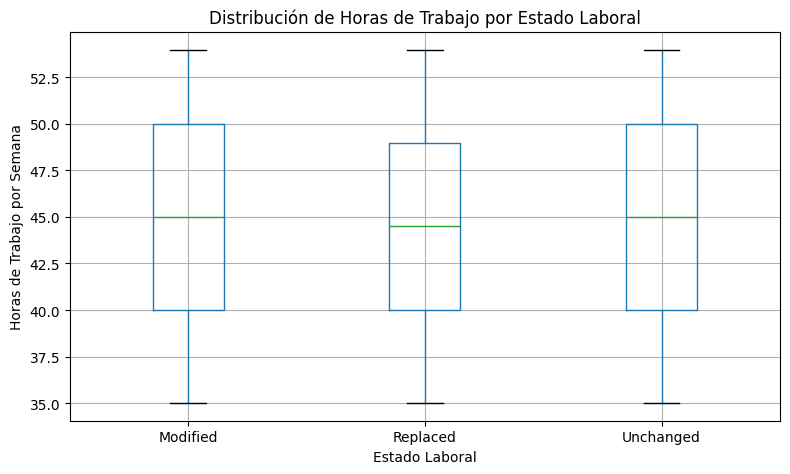

In [ ]:
# Boxplot de horas de trabajo por estado laboral
fig, ax = plt.subplots(figsize=(8, 5))
data.boxplot(column='Work_Hours_Per_Week', by='Job_Status', ax=ax)
ax.set_title('Distribución de Horas de Trabajo por Estado Laboral')
ax.set_xlabel('Estado Laboral')
ax.set_ylabel('Horas de Trabajo por Semana')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Respuesta a Pregunta 2:** Al aplicar el método del rango intercuartílico (IQR) sobre `Work_Hours_Per_Week` se obtuvieron Q1 = 40 y Q3 = 50 (IQR = 10), lo que define los límites en [25, 65] horas semanales. Como los valores reales de la variable se encuentran entre 35 y 54 horas, **no se detectaron valores atípicos**: los 2000 empleados quedan clasificados como "Normal".

Al comparar la distribución por estado laboral, las horas semanales son prácticamente iguales en los tres grupos: `Replaced` (media ≈ 44.67), `Modified` (≈ 44.88) y `Unchanged` (≈ 44.85), con desviaciones estándar similares (~5.7–6.0) y los mismos mínimos y máximos (35–54). El boxplot confirma que las cajas se solapan casi por completo y no hay puntos fuera de los bigotes.

**Conclusión:** la cantidad de horas trabajadas por semana no es un factor que diferencie a los empleados reemplazados, modificados o sin cambios por la IA; el impacto laboral parece estar asociado a otras variables (industria, rol, nivel de adopción de IA) y no a la carga horaria.



### 3. ¿Qué porcentaje de empleados con alto nivel de adopción de IA reportaron un cambio positivo en productividad, y cómo se compara con los de bajo nivel de adopción?


In [ ]:
# Filtrar por nivel de adopción de IA y calcular productividad positiva
data['Productividad_Positiva'] = data['Productivity_Change_%'] > 0

# Agrupar por nivel de adopción de IA
productividad_por_ai = data.groupby('AI_Adoption_Level').agg(
    Total_Empleados=('Employee_ID', 'count'),
    Empleados_Productividad_Positiva=('Productividad_Positiva', 'sum'),
    Productividad_Promedio=('Productivity_Change_%', 'mean')
)

productividad_por_ai['Porcentaje_Productividad_Positiva'] = (
    productividad_por_ai['Empleados_Productividad_Positiva'] / productividad_por_ai['Total_Empleados'] * 100
).round(2)

# Ordenar por nivel: Low, Medium, High
productividad_por_ai = productividad_por_ai.reindex(['Low', 'Medium', 'High'])
productividad_por_ai

,Total_Empleados,Empleados_Productividad_Positiva,Productividad_Promedio,Porcentaje_Productividad_Positiva
AI_Adoption_Level,,,,
Low,618,377,8.031262,61.00
Medium,677,446,10.174579,65.88
High,705,491,10.950539,69.65


**Respuesta Pregunta 3:** Se crea la variable booleana `Productividad_Positiva`, que toma el valor `True` cuando `Productivity_Change_%` es mayor a 0, y se agruparon los empleados según su nivel de adopción de IA (`Low`, `Medium`, `High`).

Los resultados muestran una **relación directa entre el nivel de adopción de IA y la mejora en productividad**. En el grupo con adopción **baja** se analizaron 618 empleados, de los cuales el **61.00 %** reportó un cambio positivo en productividad, con un incremento promedio del **8.03 %**. En el grupo con adopción **media**, conformado por 677 empleados, el porcentaje sube al **65.88 %** y el cambio promedio alcanza el **10.17 %**. Finalmente, en el grupo con adopción **alta** (705 empleados) la proporción de empleados beneficiados llega al **69.65 %** y el cambio promedio se ubica en **10.95 %**.

Comparando los extremos, el grupo de adopción alta supera al de adopción baja en aproximadamente **8.6 puntos porcentuales** en cuanto a empleados con productividad positiva, y el cambio promedio crece cerca de **3 puntos porcentuales** entre ambos niveles, mostrando una progresión consistente a medida que aumenta la adopción de IA.

**Conclusión:** los datos sugieren que una mayor adopción de IA está asociada tanto a una **mayor proporción de empleados beneficiados** como a un **incremento promedio más alto en la productividad**. Aunque el efecto no es extremo (incluso en adopción baja más del 60 % mejora), la tendencia confirma que integrar la IA al trabajo tiende a impactar positivamente el rendimiento laboral.
